# Workshop D.2: Evaluating Learned Representations
## Notebook 5.b — Organization of Representations

This notebook evaluates organization of frozen ResNet representations on STL-10 using the Representation Evaluation Recipe Card.

**Learning Objectives:**- Compare pretrained vs. random representations

- Learn the standard recipe for evaluating representation properties- 
- Evaluate **informativeness**: is the information organized properly in  Z?


In [7]:
# --- Imports: standard libs, numpy/pandas, plotting, torch, torchvision, sklearn
import os
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
from torchvision.models import (resnet18, resnet34, ResNet18_Weights, ResNet34_Weights)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error

# Suppress noisy warnings in notebook output
warnings.filterwarnings("ignore")

---
## Step 1: Load the Dataset

Define a small, editable config dataclass so the notebook runs quickly on a laptop/Colab.

**Recipe Card:** Load the Dataset of interest (evaluation dataset)  ### Configuration

$\mathcal{D} = \{x_i, y_i\}_{i=1}^N$

- **Factors of variation:** Brightness and hue of original images

For this notebook, we use STL-10 with controlled factors:- **Task:** Object class (10 classes)

In [8]:
@dataclass
class Config:
    # Data
    data_root: str = "./data"
    dataset_name: str = "STL10"
    image_size: int = 224

    # Keep these modest for a laptop/Colab. Increase later for stronger results.
    num_train_samples: int = 1000
    num_test_samples: int = 500

    # Dataloader
    batch_size: int = 64
    num_workers: int = 2

    # Models
    model_names: Tuple[str, ...] = ("resnet18", "resnet34", "resnet18_random")

    # Controlled factors for informativeness
    brightness_values: Tuple[float, ...] = (0.6, 0.8, 1.0, 1.2, 1.4)
    hue_values: Tuple[float, ...] = (-0.2, -0.1, 0.0, 0.1, 0.2)

    # Reproducibility
    random_seed: int = 42

cfg = Config()

# Quick sanity print
print("Config: data_root=", cfg.data_root, "image_size=", cfg.image_size)

Config: data_root= ./data image_size= 224


### Reproducibility & Device
Set random seeds and choose CPU/GPU device.

In [9]:
def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility across numpy, random, and torch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.random_seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Plot Style & Colors
Configure matplotlib and color mappings used for plots.

In [10]:
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

model_colors = {
    "resnet18": "#1f77b4",
    "resnet34": "#ff7f0e",
    "resnet18_random": "#7f7f7f",
}

task_colors = {
    "class": "#4c72b0",
    "brightness": "#55a868",
    "hue": "#c44e52",
}

### ImageNet Normalization Constants
Used before feeding images to the pretrained ResNets.

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

### Step 2: Define Task-Specific Functions & Transformations


**Recipe Card:** Define optional transformations  Resize, tensorize, and normalize images for the frozen ResNet encoder.

$x_i' = T_\alpha(x_i)$**Transform: STL-10 Encoder Transform**



Examples: noise, crop, rotation, brightness shift, gene dropout, domain shift, translation.For this notebook, we define an encoder-ready transform and factor extraction functions.


In [12]:
class STL10EncoderTransform:
    """Resize, tensorize, and normalize images for the encoder."""
    def __init__(self, image_size: int = 224):
        self.image_size = image_size
        self.resize = transforms.Resize((image_size, image_size))
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __call__(self, img):
        img = self.resize(img)
        img = self.to_tensor(img)
        img = self.normalize(img)
        return img

### Dataset Helpers
Small helpers to create reproducible subsets and DataLoaders.

In [13]:
def make_subset(dataset, n_samples: int, seed: int) -> Subset:
    """Return a reproducible random subset of a dataset."""
    rng = np.random.default_rng(seed)
    n_samples = min(n_samples, len(dataset))
    indices = rng.choice(len(dataset), size=n_samples, replace=False)
    return Subset(dataset, indices.tolist())

def make_stl10_dataset(split: str):
    transform = STL10EncoderTransform(image_size=cfg.image_size)
    dataset = datasets.STL10(root=cfg.data_root, split=split, download=True, transform=transform)
    return dataset

def make_raw_stl10_dataset(split: str):
    dataset = datasets.STL10(root=cfg.data_root, split=split, download=True, transform=None)
    return dataset

def make_dataloader(dataset, shuffle: bool = False) -> DataLoader:
    return DataLoader(dataset, batch_size=cfg.batch_size, shuffle=shuffle, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

### Load Datasets (Subsets)
Create small reproducible train/test subsets for faster runs.

In [14]:
clean_train_full = make_stl10_dataset(split="train")
clean_test_full = make_stl10_dataset(split="test")

train_subset = make_subset(clean_train_full, n_samples=cfg.num_train_samples, seed=cfg.random_seed)
test_subset = make_subset(clean_test_full, n_samples=cfg.num_test_samples, seed=cfg.random_seed + 1)

train_loader = make_dataloader(train_subset, shuffle=False)
test_loader = make_dataloader(test_subset, shuffle=False)

print(f"Train subset size: {len(train_subset)}")
print(f"Test subset size:  {len(test_subset)}")

Files already downloaded and verified
Files already downloaded and verified
Train subset size: 1000
Test subset size:  500


---
## Step 3: Encoder & Representation

Wrap torchvision ResNet to expose the avgpool 512-d embedding and freeze parameters.

**Recipe Card:** Encoder and representation  ### ResNet Encoder Wrapper

-Load an encoder: $f_\theta$  

-Choose the layer used as the representation: $z_i = f_\theta(x_i)$  - Freeze encoder: `requires_grad = False` in PyTorch

-Examples: penultimate layer, bottleneck, CLS token, pooled graph/set embedding.- Representation layer: Average pooled output (512-d)

- Encoder: Frozen pretrained ResNet (resnet18, resnet34) or random ResNet18
**For this notebook:**

In [15]:
class ResNetAvgPoolEncoder(nn.Module):
    """Return 512-d avgpool features from a torchvision ResNet."""
    def __init__(self, resnet_model: nn.Module):
        super().__init__()
        # Keep all layers except final fully-connected classifier
        self.backbone = nn.Sequential(*list(resnet_model.children())[:-1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.backbone(x)  # [B, 512, 1, 1]
        z = torch.flatten(z, start_dim=1)  # [B, 512]
        return z

def get_resnet_encoder(model_name: str, device: torch.device) -> nn.Module:
    if model_name == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    elif model_name == "resnet34":
        model = resnet34(weights=ResNet34_Weights.DEFAULT)
    elif model_name == "resnet18_random":
        model = resnet18(weights=None)
    else:
        raise ValueError("model_name must be one of: 'resnet18', 'resnet34', 'resnet18_random'.")

    encoder = ResNetAvgPoolEncoder(model)
    # Freeze encoder and move to device
    encoder.eval()
    for p in encoder.parameters(): p.requires_grad = False
    return encoder.to(device)

### Embedding Extraction
Utility to run the frozen encoder over a DataLoader and return numpy arrays.

In [16]:
@torch.no_grad()
def extract_embeddings(encoder: nn.Module, dataloader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    encoder.eval()
    all_Z, all_y = [], []
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        z_batch = encoder(x_batch)
        z_batch = z_batch.detach().cpu().numpy()
        all_Z.append(z_batch)
        all_y.append(np.asarray(y_batch))
    Z = np.concatenate(all_Z, axis=0)
    y = np.concatenate(all_y, axis=0)
    return Z, y

---
## Step 4: Probe Model (not needed here)


---
## Step 5: Evaluation Plugin — Organization

We now evaluate the **organization** of the learned representations using five standard methods:

1. **b1. kNN Retrieval** — Do nearby representations retrieve examples from the same class?
2. **b2. Clustering Quality** — How well do unsupervised clusters align with class labels?
3. **b3. Similarity Matrix** — Visualize pairwise distances between representations.
4. **b4. Intrinsic Dimensionality** — How many dimensions are actually used?
5. **b5. Visualization** — What do 2D projections reveal?

Each analysis requires the **extracted embeddings** $Z_\text{train}, Z_\text{test}$ from the frozen encoder. We first extract and cache these embeddings for all three models, then run each analysis separately.

In [17]:
# Extract and cache embeddings for all models
feature_store = {}
for model_name in cfg.model_names:
    print(f"Extracting embeddings for {model_name}...")
    encoder = get_resnet_encoder(model_name, device)
    Z_train, y_train = extract_embeddings(encoder, train_loader, device)
    Z_test, y_test = extract_embeddings(encoder, test_loader, device)
    feature_store[model_name] = {
        "Z_train": Z_train,
        "y_train": y_train,
        "Z_test": Z_test,
        "y_test": y_test
    }
    print(f"  Z_train: {Z_train.shape}, Z_test: {Z_test.shape}")
print("\nEmbeddings extracted and cached.")


Extracting embeddings for resnet18...
  Z_train: (1000, 512), Z_test: (500, 512)
Extracting embeddings for resnet34...
  Z_train: (1000, 512), Z_test: (500, 512)
Extracting embeddings for resnet18_random...
  Z_train: (1000, 512), Z_test: (500, 512)

Embeddings extracted and cached.


---
### b1. kNN Retrieval — Semantic Coherence

**Concept:** In a well-organized representation space, nearby points should have the same semantic label. We measure this by computing k-nearest neighbors and checking if the retrieved neighbors share the true class label.

**Mathematical Foundation:**
- Given embeddings $Z = \{z_1, \ldots, z_N\}$ and class labels $y = \{y_1, \ldots, y_N\}$
- For each test point $z_i$, find its $k$ nearest neighbors in the training set: $NN_k(z_i) = \{z_{j_1}, \ldots, z_{j_k} : \text{smallest Euclidean distances to } z_i\}$
- Compute **label agreement**: fraction of neighbors with the same label: $\text{Agree}_i = \frac{1}{k} \sum_{j \in NN_k(z_i)} \mathbb{1}[y_j = y_i]$
- Report average label agreement across test set

**Metrics:**
- **kNN Label Agreement** (%) — What fraction of the k nearest neighbors have the same label? (Higher is better)
- **kNN Classification Accuracy** (%) — Use majority vote from k neighbors as the classifier. How often is the majority-voted label correct? (Higher is better)

**Exact Tasks:**
1. Extract train and test embeddings from `feature_store[model_name]`
2. Build a kNN index on training embeddings (e.g., NearestNeighbors from sklearn)
3. For each test point, retrieve k=5 nearest neighbors from training set
4. Count label agreements and compute mean agreement score
5. Also fit a KNeighborsClassifier and report accuracy
6. Create a table of results, and visualize with a bar plot

**Expected Outputs:**
- A table showing: **model_name** | **kNN Label Agreement (%)** | **kNN Classification Accuracy (%)**
- A bar plot comparing the two metrics across the three models (resnet18, resnet34, resnet18_random)
- Optionally, a grid of retrieved neighbors for a few sample test points (showing query + k nearest neighbors)

b1. kNN Retrieval Results:
          Model kNN Label Agreement (%) kNN Classification Accuracy (%)
       resnet18                    85.6                            90.4
       resnet34                    89.7                            93.4
resnet18_random                    19.2                            21.0


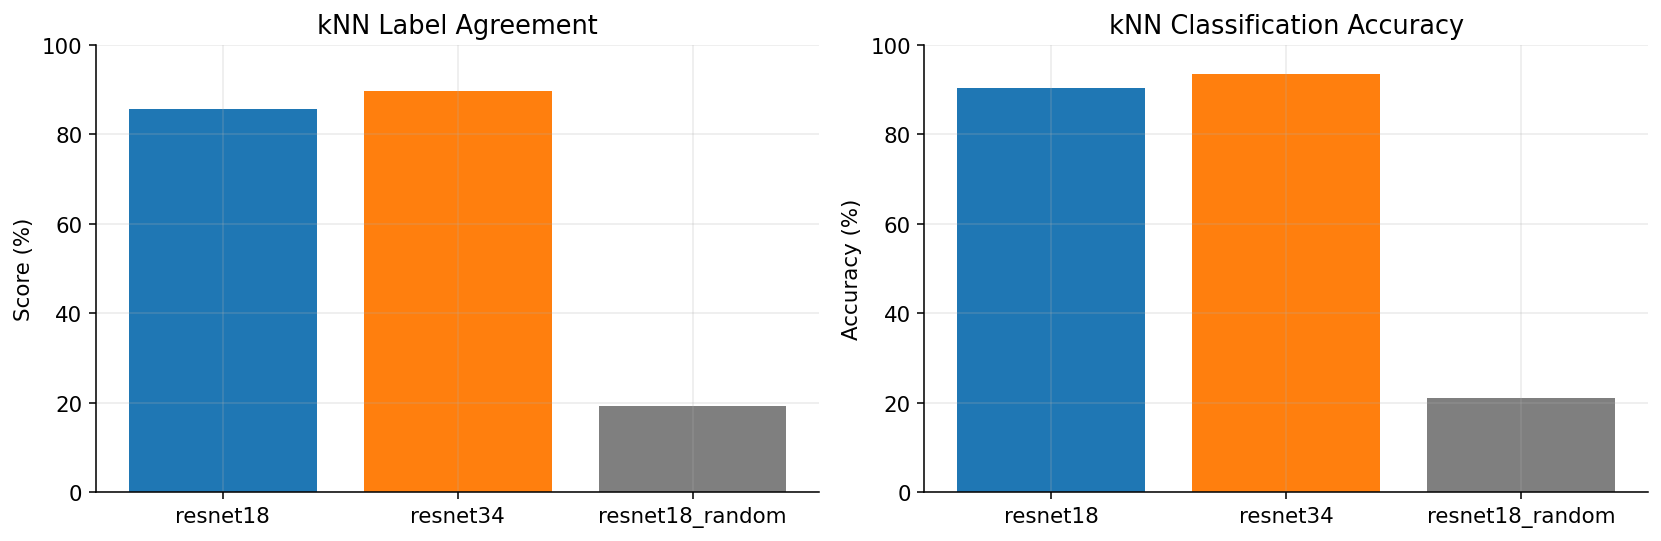

In [18]:
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

# b1. kNN Retrieval
results_b1 = []
for model_name in cfg.model_names:
    Z_train = feature_store[model_name]["Z_train"]
    y_train = feature_store[model_name]["y_train"]
    Z_test = feature_store[model_name]["Z_test"]
    y_test = feature_store[model_name]["y_test"]
    
    # Compute kNN label agreement
    k = 5
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(Z_train)
    distances, indices = nbrs.kneighbors(Z_test)
    
    # Label agreement: fraction of k nearest neighbors with same label
    agreements = []
    for i, test_idx in enumerate(range(len(y_test))):
        neighbor_labels = y_train[indices[i]]
        same_label = (neighbor_labels == y_test[test_idx]).sum()
        agreement = same_label / k
        agreements.append(agreement)
    
    knn_label_agreement = np.mean(agreements) * 100
    
    # kNN Classification Accuracy
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(Z_train, y_train)
    knn_accuracy = knn_clf.score(Z_test, y_test) * 100
    
    results_b1.append({
        "Model": model_name,
        "kNN Label Agreement (%)": f"{knn_label_agreement:.1f}",
        "kNN Classification Accuracy (%)": f"{knn_accuracy:.1f}"
    })

results_b1_df = pd.DataFrame(results_b1)
print("b1. kNN Retrieval Results:")
print(results_b1_df.to_string(index=False))

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = [r["Model"] for r in results_b1]
agreement_scores = [float(r["kNN Label Agreement (%)"]) for r in results_b1]
accuracy_scores = [float(r["kNN Classification Accuracy (%)"]) for r in results_b1]

axes[0].bar(model_names, agreement_scores, color=[model_colors.get(m, "#999") for m in model_names])
axes[0].set_ylabel("Score (%)")
axes[0].set_title("kNN Label Agreement")
axes[0].set_ylim([0, 100])

axes[1].bar(model_names, accuracy_scores, color=[model_colors.get(m, "#999") for m in model_names])
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("kNN Classification Accuracy")
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()


---
### b2. Clustering Quality — Semantic Separation

**Concept:** Well-organized representations should cluster naturally such that unsupervised clusters correspond to semantic classes. We measure this using standard clustering metrics.

**Mathematical Foundation:**
- Apply k-means clustering to the training embeddings $Z_\text{train}$, with $k=10$ (number of classes)
- Compare cluster assignments to ground-truth labels using three metrics:
  - **Adjusted Rand Index (ARI)**: Measures similarity between two partitions, range $[-1, 1]$, where $1$ = perfect agreement, $0$ = random agreement
  - **Normalized Mutual Information (NMI)**: Measures information shared between cluster and class labels, range $[0, 1]$, where $1$ = perfect alignment
  - **Silhouette Score**: Measures how well-separated clusters are, range $[-1, 1]$, where $1$ = well-separated, $0$ = overlapping

**Metrics:**
- **ARI** (—) — Adjusted Rand Index: Higher is better
- **NMI** (—) — Normalized Mutual Information: Higher is better
- **Silhouette** (—) — Silhouette Score: Higher is better

**Exact Tasks:**
1. Extract train embeddings from `feature_store[model_name]`
2. Apply k-means with $k=10$ clusters to training set
3. Compute ARI, NMI, and Silhouette score by comparing cluster assignments to true labels
4. Create a table of results
5. Visualize with a grouped bar plot

**Expected Outputs:**
- A table showing: **model_name** | **ARI** | **NMI** | **Silhouette**
- A grouped bar plot showing all three metrics for the three models
- (Optional) A 2D scatter plot of the train embeddings colored by k-means clusters vs. colored by true class labels

b2. Clustering Quality Results:
          Model   ARI   NMI Silhouette
       resnet18 0.736 0.794      0.079
       resnet34 0.864 0.880      0.093
resnet18_random 0.021 0.067      0.173


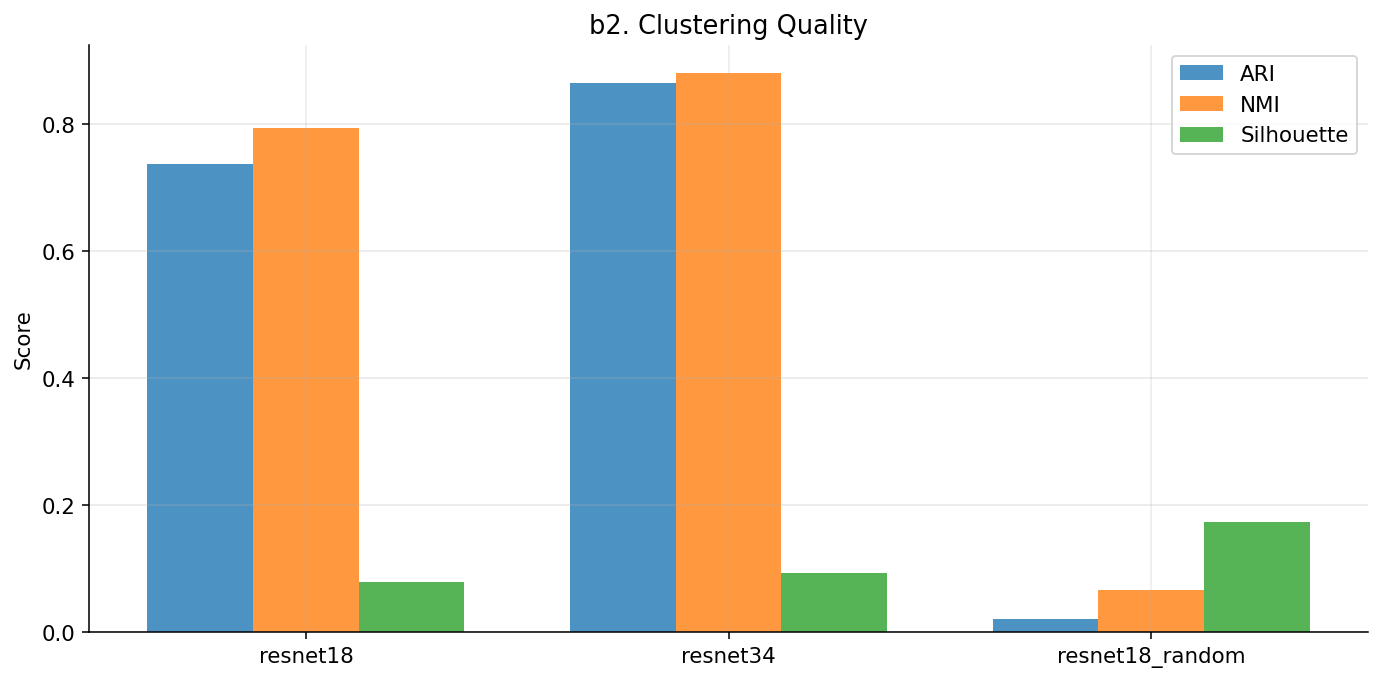

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# b2. Clustering Quality
results_b2 = []
for model_name in cfg.model_names:
    Z_train = feature_store[model_name]["Z_train"]
    y_train = feature_store[model_name]["y_train"]
    
    # Apply k-means
    kmeans = KMeans(n_clusters=10, random_state=cfg.random_seed, n_init=10)
    cluster_labels = kmeans.fit_predict(Z_train)
    
    # Compute metrics
    ari = adjusted_rand_score(y_train, cluster_labels)
    nmi = normalized_mutual_info_score(y_train, cluster_labels)
    sil = silhouette_score(Z_train, cluster_labels)
    
    results_b2.append({
        "Model": model_name,
        "ARI": f"{ari:.3f}",
        "NMI": f"{nmi:.3f}",
        "Silhouette": f"{sil:.3f}"
    })

results_b2_df = pd.DataFrame(results_b2)
print("b2. Clustering Quality Results:")
print(results_b2_df.to_string(index=False))

# Grouped bar plot
fig, ax = plt.subplots(figsize=(10, 5))
model_names = [r["Model"] for r in results_b2]
ari_scores = [float(r["ARI"]) for r in results_b2]
nmi_scores = [float(r["NMI"]) for r in results_b2]
sil_scores = [float(r["Silhouette"]) for r in results_b2]

x = np.arange(len(model_names))
width = 0.25

ax.bar(x - width, ari_scores, width, label="ARI", alpha=0.8)
ax.bar(x, nmi_scores, width, label="NMI", alpha=0.8)
ax.bar(x + width, sil_scores, width, label="Silhouette", alpha=0.8)

ax.set_ylabel("Score")
ax.set_title("b2. Clustering Quality")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### b3. Similarity Matrix — Visual Structure
#### How similarity is calculated


For each model, we first extract a representation vector for each image:

$$z_i = f_\theta(x_i)$$

where:

- $x_i$ is the input image
- $f_\theta$ is the frozen ResNet encoder
- $z_i \in \mathbb{R}^{512}$ is the avgpool / penultimate representation

We then compute pairwise similarity between all selected embeddings using **cosine similarity**.

This creates a kernel / similarity matrix:

$$K_{ij} = \mathrm{cosine}(z_i, z_j)$$

where each entry compares image $i$ and image $j$:

$$K_{ij} = \frac{z_i^\top z_j}{\|z_i\| \|z_j\|}$$

Interpretation:

- $K_{ij} = 1$: the two representations point in the same direction
- $K_{ij} \approx 0$: the two representations are nearly orthogonal
- $K_{ij} < 0$: the two representations point in opposite directions

The diagonal entries are always high because each sample is compared with itself:

$$K_{ii} = 1$$

After computing the similarity matrix, we sort samples by class label. This does **not** change the similarities. It only rearranges rows and columns so that examples from the same class appear next to each other.

If the representation is organized by class, then the sorted similarity matrix should show block-like structure along the diagonal.

---

## Same-class and different-class similarity

To quantify this block structure, we compare two averages.

### Same-class similarity

$$\mathrm{SameSim} = \mathrm{mean}(K_{ij} \mid y_i = y_j,\ i \neq j)$$

This measures how similar examples from the same class are.

### Different-class similarity

$$\mathrm{DiffSim} = \mathrm{mean}(K_{ij} \mid y_i \neq y_j)$$

This measures how similar examples from different classes are.

### Similarity gap

$$\mathrm{Gap} = \mathrm{SameSim} - \mathrm{DiffSim}$$

A larger similarity gap means the representation gives higher similarity to same-class examples than to different-class examples.

Therefore, the similarity gap is a simple measure of class-based organization in the representation space.

---

## Kernel-to-kernel comparison

We can also compare the similarity matrices from two different models.

For example:

> Does ResNet18 organize the samples similarly to ResNet34?

To do this, we compare the off-diagonal entries of their kernel matrices.

The diagonal entries are ignored because they are self-similarities:

$$K_{ii} = 1$$

For two models $A$ and $B$, we compute the correlation between corresponding off-diagonal kernel entries:

$$\mathrm{corr}\left(K^{(A)}_{ij}, K^{(B)}_{ij}\right) \quad \text{for } i \neq j$$

This asks:

> If model A thinks two images are similar, does model B also think those two images are similar?

A high kernel-to-kernel correlation means the two models organize pairwise relationships in a similar way.

A low kernel-to-kernel correlation means the two models organize the same samples differently.

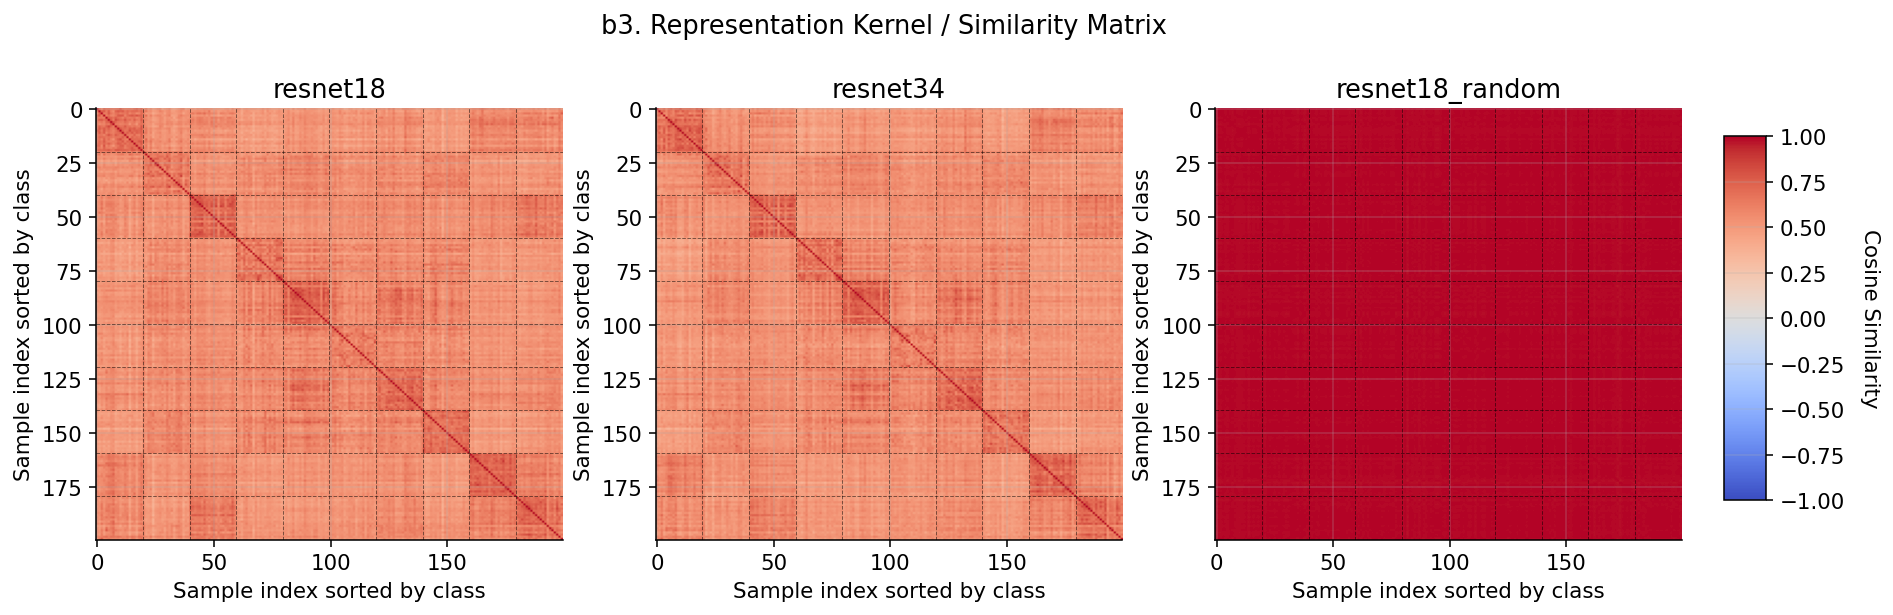

b3. Kernel Summary:
          Model  Same-Class Similarity  Different-Class Similarity  Similarity Gap
       resnet18                 0.6846                      0.5505          0.1340
       resnet34                 0.6828                      0.5425          0.1403
resnet18_random                 0.9929                      0.9923          0.0006


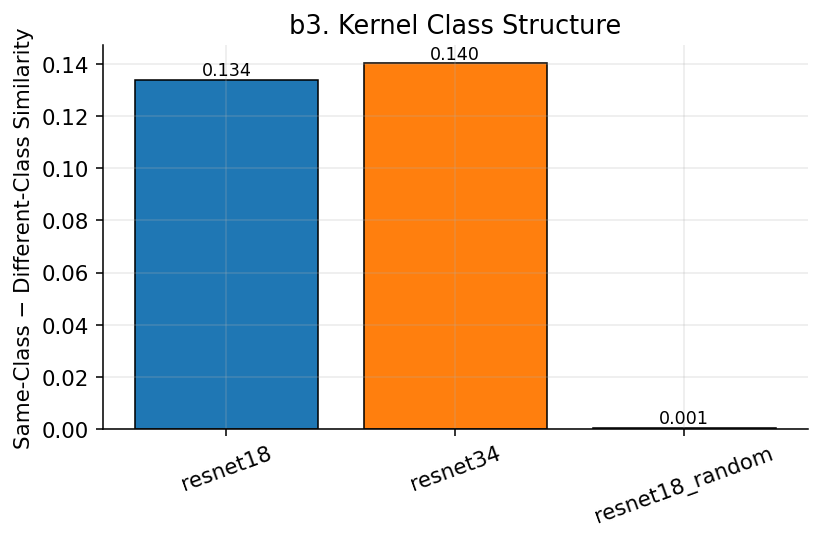


Kernel-to-Kernel Similarity:
                 resnet18  resnet34  resnet18_random
resnet18            1.000     0.844            0.139
resnet34            0.844     1.000            0.163
resnet18_random     0.139     0.163            1.000


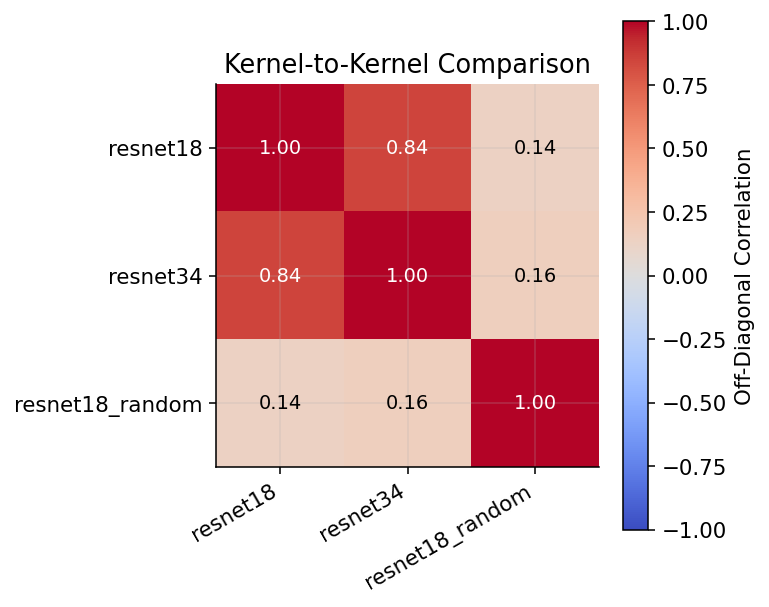

In [22]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# b3. Similarity Matrix / Kernel Matrix
# ============================================================

# If cfg is not defined, infer model names directly from feature_store
model_names = list(feature_store.keys())

# Or use fixed order if you prefer:
# model_names = ["resnet18", "resnet34", "resnet18_random"]

samples_per_class = 20

kernels = {}
sorted_labels_by_model = {}
kernel_summary = []

# ------------------------------------------------------------
# Use the same balanced subset for all models
# ------------------------------------------------------------
# This is important because kernel comparison only makes sense
# if every model uses the same samples in the same order.

reference_model = model_names[0]
y_ref = feature_store[reference_model]["y_train"]

balanced_indices = []

for class_id in range(10):
    class_mask = (y_ref == class_id)
    class_indices = np.where(class_mask)[0]
    
    # Take first 20 samples from each class
    balanced_indices.extend(class_indices[:samples_per_class])

balanced_indices = np.array(balanced_indices)


# ------------------------------------------------------------
# Plot similarity/kernel matrix for each model
# ------------------------------------------------------------

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))

if len(model_names) == 1:
    axes = [axes]

last_im = None

for ax, model_name in zip(axes, model_names):
    
    Z_train = feature_store[model_name]["Z_train"]
    y_train = feature_store[model_name]["y_train"]
    
    # Use the same samples for every model
    Z_balanced = Z_train[balanced_indices]
    y_balanced = y_train[balanced_indices]
    
    # Compute cosine similarity kernel
    similarity = cosine_similarity(Z_balanced)
    
    # Sort by class label to reveal block structure
    sort_idx = np.argsort(y_balanced)
    similarity_sorted = similarity[np.ix_(sort_idx, sort_idx)]
    y_sorted = y_balanced[sort_idx]
    
    # Store kernels for model-to-model comparison
    kernels[model_name] = similarity_sorted
    sorted_labels_by_model[model_name] = y_sorted
    
    # --------------------------------------------------------
    # Same-class vs different-class similarity
    # --------------------------------------------------------
    n = len(y_sorted)
    
    same_mask = y_sorted[:, None] == y_sorted[None, :]
    diff_mask = y_sorted[:, None] != y_sorted[None, :]
    off_diag_mask = ~np.eye(n, dtype=bool)
    
    same_values = similarity_sorted[same_mask & off_diag_mask]
    diff_values = similarity_sorted[diff_mask]
    
    same_mean = same_values.mean()
    diff_mean = diff_values.mean()
    similarity_gap = same_mean - diff_mean
    
    kernel_summary.append({
        "Model": model_name,
        "Same-Class Similarity": same_mean,
        "Different-Class Similarity": diff_mean,
        "Similarity Gap": similarity_gap,
    })
    
    # --------------------------------------------------------
    # Visualize kernel matrix
    # --------------------------------------------------------
    last_im = ax.imshow(
        similarity_sorted,
        cmap="coolwarm",
        aspect="auto",
        vmin=-1,
        vmax=1
    )
    
    ax.set_title(f"{model_name}")
    ax.set_xlabel("Sample index sorted by class")
    ax.set_ylabel("Sample index sorted by class")
    
    # Add class boundaries
    for class_id in range(1, 10):
        boundary = class_id * samples_per_class
        
        ax.axhline(
            y=boundary - 0.5,
            color="black",
            linewidth=0.5,
            linestyle="--",
            alpha=0.5
        )
        
        ax.axvline(
            x=boundary - 0.5,
            color="black",
            linewidth=0.5,
            linestyle="--",
            alpha=0.5
        )


# Add colorbar
fig.subplots_adjust(right=0.88)

cbar_ax = fig.add_axes([0.90, 0.18, 0.02, 0.65])
cbar = fig.colorbar(last_im, cax=cbar_ax)
cbar.ax.yaxis.set_ticks_position("right")
cbar.ax.yaxis.set_label_position("right")
cbar.set_label("Cosine Similarity", rotation=270, labelpad=18)

plt.suptitle("b3. Representation Kernel / Similarity Matrix", y=1.05)
plt.show()


# ------------------------------------------------------------
# Print kernel summary
# ------------------------------------------------------------

kernel_summary_df = pd.DataFrame(kernel_summary)

print("b3. Kernel Summary:")
print(kernel_summary_df.round(4).to_string(index=False))


# ------------------------------------------------------------
# Plot similarity gap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

models = kernel_summary_df["Model"].tolist()
gaps = kernel_summary_df["Similarity Gap"].values

# Use model_colors if it exists, otherwise use default gray
if "model_colors" in globals():
    colors = [model_colors.get(m, "#999999") for m in models]
else:
    colors = ["#999999"] * len(models)

ax.bar(
    models,
    gaps,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)

ax.set_ylabel("Same-Class − Different-Class Similarity")
ax.set_title("b3. Kernel Class Structure")

for i, val in enumerate(gaps):
    ax.text(
        i,
        val,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ============================================================
# Compare kernels between models
# ============================================================

def offdiag_kernel_correlation(K1, K2):
    """
    Compare two kernels by correlating their off-diagonal entries.

    This asks:
    If model A thinks sample i and sample j are similar,
    does model B also think sample i and sample j are similar?
    """
    
    n = K1.shape[0]
    
    # Ignore diagonal self-similarity
    off_diag_mask = ~np.eye(n, dtype=bool)
    
    v1 = K1[off_diag_mask]
    v2 = K2[off_diag_mask]
    
    if np.std(v1) == 0 or np.std(v2) == 0:
        return np.nan
    
    return np.corrcoef(v1, v2)[0, 1]


kernel_corr = np.zeros((len(model_names), len(model_names)))

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        kernel_corr[i, j] = offdiag_kernel_correlation(
            kernels[m1],
            kernels[m2],
        )


kernel_corr_df = pd.DataFrame(
    kernel_corr,
    index=model_names,
    columns=model_names,
)

print("\nKernel-to-Kernel Similarity:")
print(kernel_corr_df.round(3).to_string())


# ------------------------------------------------------------
# Plot kernel-to-kernel comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.5, 4.8))

im = ax.imshow(
    kernel_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(np.arange(len(model_names)))
ax.set_yticks(np.arange(len(model_names)))

ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.set_yticklabels(model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        val = kernel_corr[i, j]
        
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="white" if abs(val) > 0.55 else "black",
            fontsize=10,
        )

ax.set_title("Kernel-to-Kernel Comparison")
fig.colorbar(im, ax=ax, label="Off-Diagonal Correlation")

plt.tight_layout()
plt.show()

In [ ]:
# here we want to compare the kernels of the different models. We can do this by looking at the similarity matrices and seeing how they differ across models. We can also compute some metrics to quantify the differences in the kernels, such as the average similarity within classes vs between classes, or the eigenvalue spectrum of the kernel matrix.


---
### b4. Intrinsic Dimensionality — Effective Rank

**Concept:** Even though embeddings are 512-dimensional, they may only use a few effective dimensions (e.g., due to PCA structure). We measure effective dimensionality using the **participation ratio** from eigenvalue analysis.

**Mathematical Foundation:**
- Apply PCA to embeddings $Z$ to get eigenvalues $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_d$
- **Cumulative explained variance**: $\text{CE}_k = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}$
- **Participation Ratio**: $PR = \frac{\left(\sum_i \lambda_i\right)^2}{\sum_i \lambda_i^2}$
  - $PR = d$ when all eigenvalues are equal (full rank)
  - $PR \ll d$ when only a few eigenvalues dominate (low effective rank)
- Higher $PR$ = more dimensions actually used

**Metrics:**
- **Participation Ratio** (—) — Effective dimensionality. Higher is better (indicates use of more dimensions)
- **Cumulative variance explained at k=10** (%) — What fraction of variance is explained by first 10 PCs?

**Exact Tasks:**
1. Extract train embeddings from `feature_store[model_name]`
2. Apply PCA to get all eigenvalues
3. Compute participation ratio: $PR = \frac{(\sum \lambda_i)^2}{\sum \lambda_i^2}$
4. Compute cumulative explained variance curve
5. Create a table of PR and cumulative variance @ k=10
6. Plot the cumulative variance curves for all three models

**Expected Outputs:**
- A table showing: **model_name** | **Participation Ratio** | **Cumulative Variance @ k=10 (%)**
- A line plot showing cumulative explained variance (%) vs. number of principal components for all three models

The PCA participation ratio and TwoNN estimates measure different aspects of representation geometry.

The PCA participation ratio is a global variance-based estimate. It asks how many principal directions are needed to explain the spread of the embeddings.

TwoNN is a local nearest-neighbor-based estimate. It asks how dimensional the data look from local distance ratios.

Here, the random ResNet has a very low PCA participation ratio but a TwoNN estimate similar to the pretrained models. This suggests that the random representation may be globally anisotropic, with most variance concentrated in a few directions, while still preserving nontrivial local neighborhood structure.

Therefore, intrinsic dimensionality should not be interpreted as a single absolute number. Different estimators capture different geometric properties.

b4. Intrinsic Dimensionality Results:
          Model  Embedding Dim  PCA Participation Ratio  PCs for 90% Var  PCs for 95% Var  Cum. Var @ 10 PCs (%)  TwoNN  MLE k=10  MLE k=20  TLE k=10  TLE k=20
       resnet18            512                    53.74              137              188                  33.86  22.11     19.65     19.65     20.42     16.58
       resnet34            512                    61.43              142              194                  31.62  21.19     18.58     18.58     18.96     15.33
resnet18_random            512                     2.89               46               91                  78.81  22.84     16.90     16.90     19.64     14.90


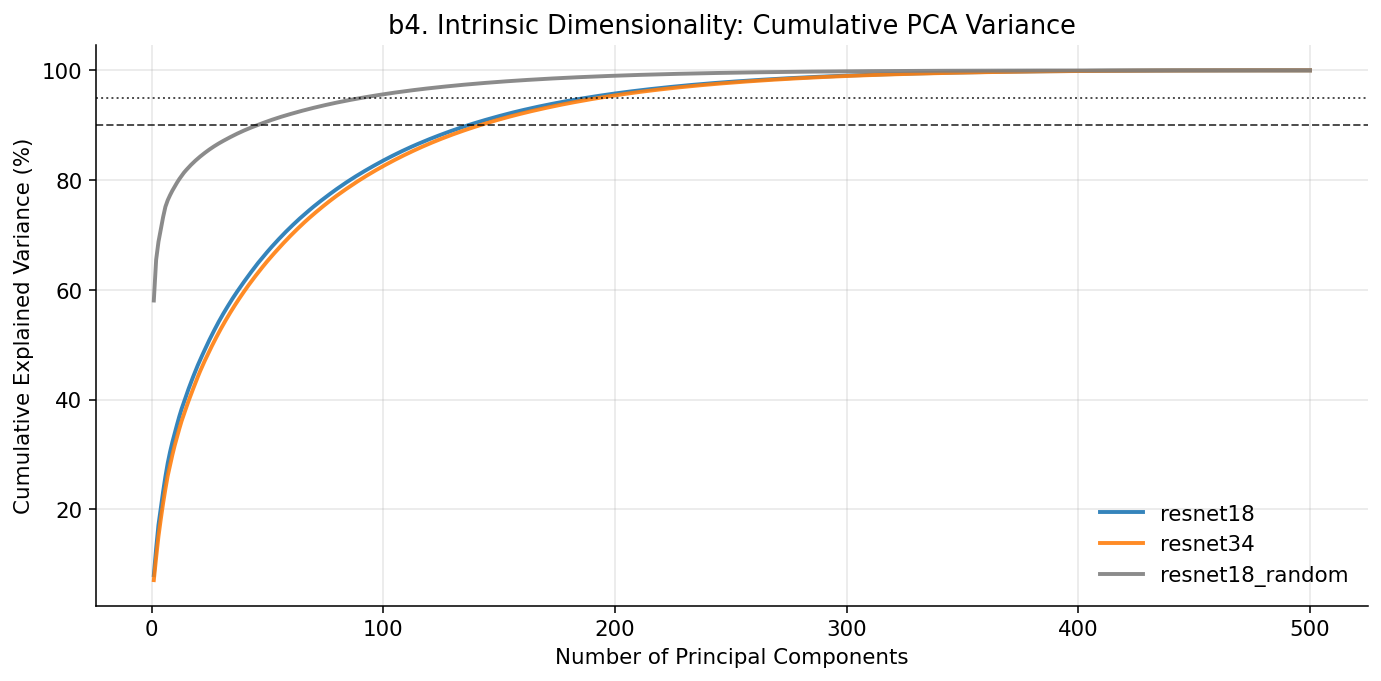

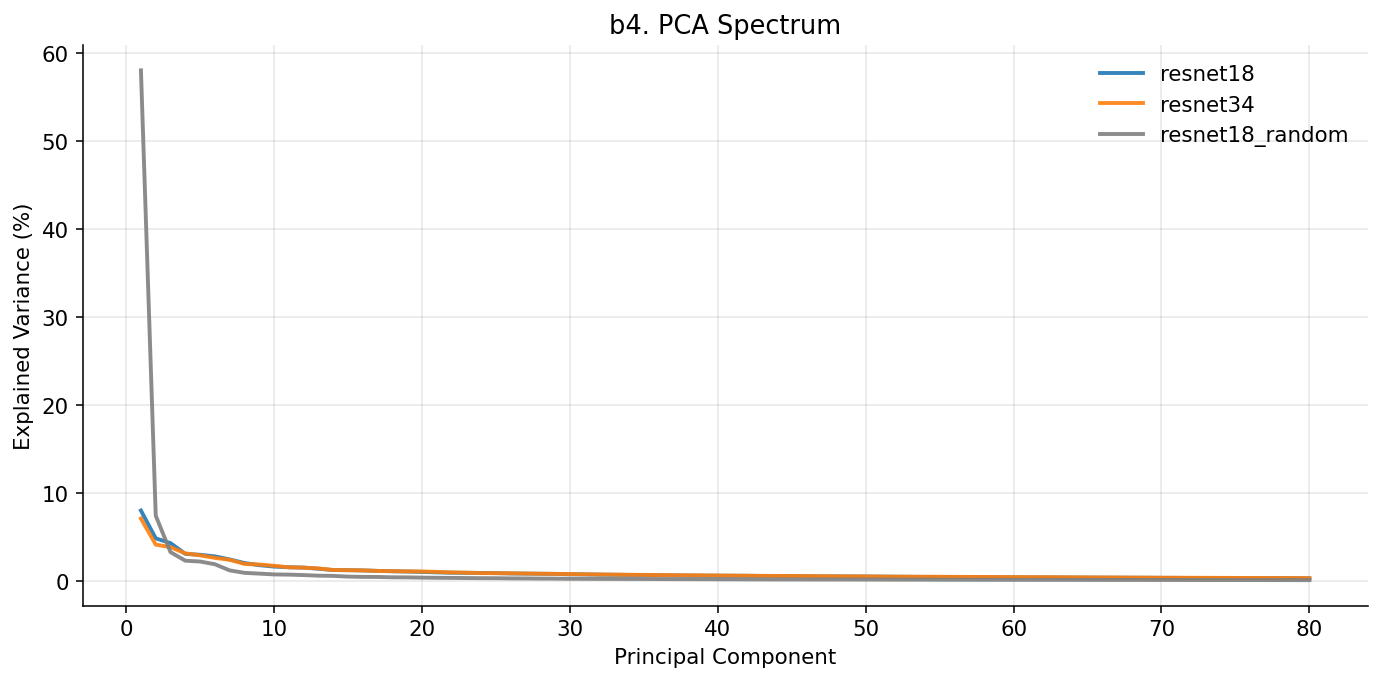

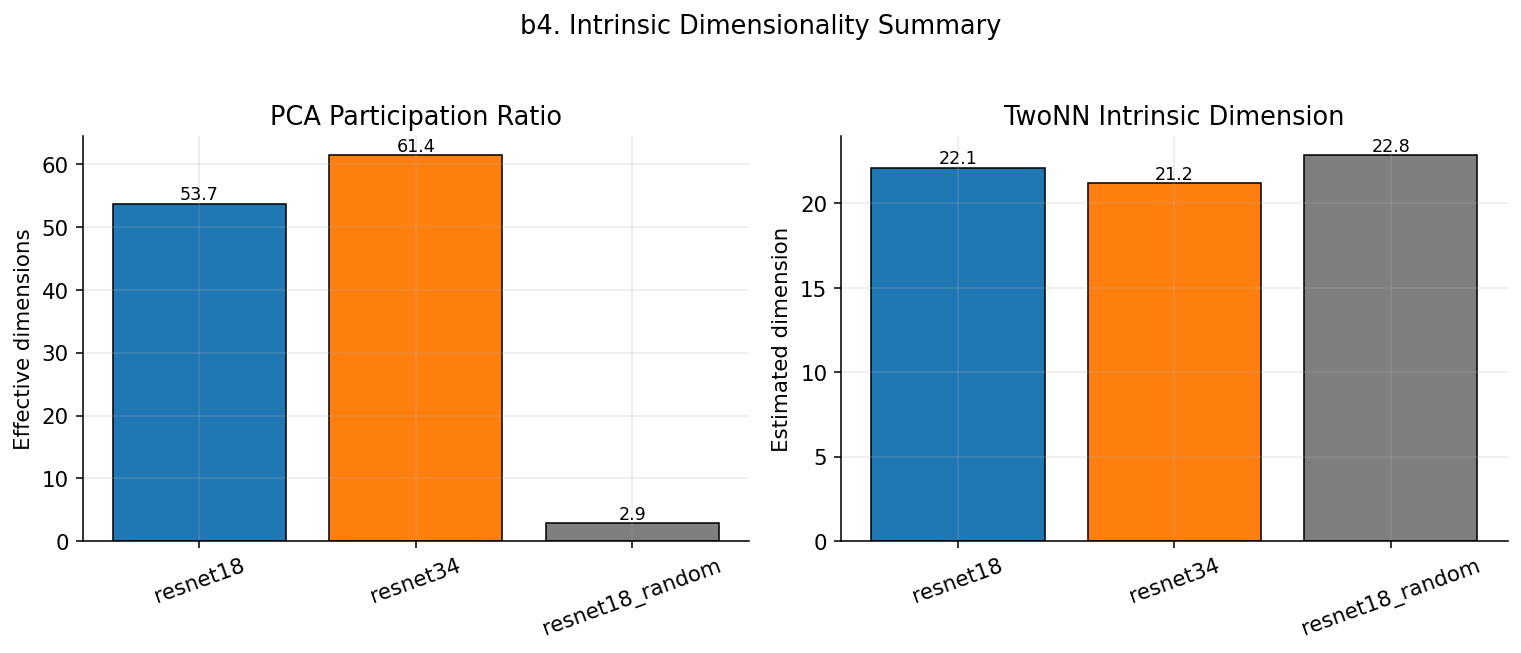

In [17]:
# ============================================================
# b4. Intrinsic Dimensionality
# ============================================================
#
# Goal:
# Estimate how many effective dimensions the representation uses.
#
# We report:
# 1. PCA participation ratio
# 2. Number of PCs needed for 90% variance
# 3. Number of PCs needed for 95% variance
# 4. Cumulative variance at k=10
# 5. Optional TwoNN / MLE / TLE estimates using skdim if available
#
# Notes:
# - PCA participation ratio is a global, variance-based estimate.
# - TwoNN / MLE / TLE are neighbor-based intrinsic dimension estimates.
# - Lower dimension is not automatically better.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Optional intrinsic dimension backend
try:
    import skdim
    HAS_SKDIM = True
except Exception:
    HAS_SKDIM = False
    print("skdim not available. TwoNN / MLE / TLE will be skipped.")


def compute_pca_intrinsic_stats(
    Z: np.ndarray,
    standardize: bool = True,
) -> dict:
    """
    Compute PCA-based effective dimensionality statistics.

    Parameters
    ----------
    Z:
        Embedding matrix with shape [N, D].

    standardize:
        If True, standardize each embedding dimension before PCA.

    Returns
    -------
    Dictionary containing:
        - participation_ratio
        - k90
        - k95
        - cumulative_variance_at_10
        - explained_variance_ratio
        - cumulative_variance
        - eigenvalues
    """

    if standardize:
        Z_in = StandardScaler().fit_transform(Z)
    else:
        Z_in = Z.copy()

    pca = PCA()
    pca.fit(Z_in)

    eigenvalues = pca.explained_variance_
    explained_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_ratio)

    # Participation ratio:
    # PR = (sum lambda)^2 / sum(lambda^2)
    lambda_sum = eigenvalues.sum()
    lambda_sum_sq = np.sum(eigenvalues ** 2)
    participation_ratio = (lambda_sum ** 2) / lambda_sum_sq

    # Number of PCs needed for 90% and 95% variance
    k90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)
    k95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)

    # Cumulative variance at first 10 PCs
    k10 = min(10, len(cumulative_variance))
    cumulative_variance_at_10 = float(cumulative_variance[k10 - 1])

    return {
        "participation_ratio": float(participation_ratio),
        "k90": k90,
        "k95": k95,
        "cumulative_variance_at_10": cumulative_variance_at_10,
        "explained_variance_ratio": explained_ratio,
        "cumulative_variance": cumulative_variance,
        "eigenvalues": eigenvalues,
    }


def estimate_neighbor_intrinsic_dimension(
    Z: np.ndarray,
    k_list: list[int] = [10, 20, 30, 50],
    standardize: bool = True,
) -> dict:
    """
    Estimate intrinsic dimensionality using neighbor-based methods.

    Uses skdim if available:
        - TwoNN
        - MLE
        - TLE

    Returns NaN values if skdim is unavailable or a method fails.
    """

    results = {}

    if standardize:
        Z_in = StandardScaler().fit_transform(Z)
    else:
        Z_in = Z.copy()

    if not HAS_SKDIM:
        results["TwoNN"] = np.nan
        for k in k_list:
            results[f"MLE_k{k}"] = np.nan
            results[f"TLE_k{k}"] = np.nan
        return results

    # TwoNN: fast global estimate
    try:
        results["TwoNN"] = float(skdim.id.TwoNN().fit_transform(Z_in))
    except Exception as e:
        print(f"TwoNN failed: {e}")
        results["TwoNN"] = np.nan

    # MLE / TLE across multiple neighborhood sizes
    for k in k_list:
        try:
            results[f"MLE_k{k}"] = float(skdim.id.MLE(K=k).fit_transform(Z_in))
        except Exception as e:
            print(f"MLE failed for k={k}: {e}")
            results[f"MLE_k{k}"] = np.nan

        try:
            results[f"TLE_k{k}"] = float(skdim.id.TLE().fit_transform(Z_in, n_neighbors=k))
        except Exception as e:
            print(f"TLE failed for k={k}: {e}")
            results[f"TLE_k{k}"] = np.nan

    return results


# ============================================================
# Run b4 for all models
# ============================================================

results_b4 = []
pca_curves = {}

# Use test embeddings for evaluation consistency.
# Use train embeddings only if you explicitly want the geometry of the training set.
for model_name in cfg.model_names:
    Z = feature_store[model_name]["Z_test"]

    pca_stats = compute_pca_intrinsic_stats(
        Z,
        standardize=True,
    )

    neighbor_stats = estimate_neighbor_intrinsic_dimension(
        Z,
        k_list=[10, 20, 30, 50],
        standardize=True,
    )

    pca_curves[model_name] = {
        "explained_variance_ratio": pca_stats["explained_variance_ratio"],
        "cumulative_variance": pca_stats["cumulative_variance"],
    }

    row = {
        "Model": model_name,
        "Embedding Dim": Z.shape[1],
        "PCA Participation Ratio": pca_stats["participation_ratio"],
        "PCs for 90% Var": pca_stats["k90"],
        "PCs for 95% Var": pca_stats["k95"],
        "Cum. Var @ 10 PCs (%)": 100 * pca_stats["cumulative_variance_at_10"],
        "TwoNN": neighbor_stats.get("TwoNN", np.nan),
        "MLE k=10": neighbor_stats.get("MLE_k10", np.nan),
        "MLE k=20": neighbor_stats.get("MLE_k20", np.nan),
        "TLE k=10": neighbor_stats.get("TLE_k10", np.nan),
        "TLE k=20": neighbor_stats.get("TLE_k20", np.nan),
    }

    results_b4.append(row)


results_b4_df = pd.DataFrame(results_b4)

# Round numeric columns for display
display_b4_df = results_b4_df.copy()
for col in display_b4_df.columns:
    if col != "Model":
        display_b4_df[col] = pd.to_numeric(display_b4_df[col], errors="ignore")
        if np.issubdtype(display_b4_df[col].dtype, np.number):
            display_b4_df[col] = display_b4_df[col].round(2)

print("b4. Intrinsic Dimensionality Results:")
print(display_b4_df.to_string(index=False))


# ============================================================
# Plot 1: Cumulative explained variance
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

for model_name in cfg.model_names:
    cumvar = pca_curves[model_name]["cumulative_variance"]
    x = np.arange(1, len(cumvar) + 1)

    ax.plot(
        x,
        100 * cumvar,
        label=model_name,
        color=model_colors.get(model_name, "#999999"),
        linewidth=2,
        alpha=0.9,
    )

ax.axhline(90, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(95, color="black", linestyle=":", linewidth=1, alpha=0.7)

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("b4. Intrinsic Dimensionality: Cumulative PCA Variance")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: Explained variance spectrum
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

max_pcs_to_show = 80

for model_name in cfg.model_names:
    evr = pca_curves[model_name]["explained_variance_ratio"]
    x = np.arange(1, min(max_pcs_to_show, len(evr)) + 1)

    ax.plot(
        x,
        100 * evr[:len(x)],
        label=model_name,
        color=model_colors.get(model_name, "#999999"),
        linewidth=2,
        alpha=0.9,
    )

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("b4. PCA Spectrum")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 3: Participation ratio and TwoNN side by side
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

models = results_b4_df["Model"].tolist()
colors = [model_colors.get(m, "#999999") for m in models]

# Participation ratio
axes[0].bar(
    models,
    results_b4_df["PCA Participation Ratio"].values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)

axes[0].set_title("PCA Participation Ratio")
axes[0].set_ylabel("Effective dimensions")
axes[0].tick_params(axis="x", rotation=20)

for i, val in enumerate(results_b4_df["PCA Participation Ratio"].values):
    axes[0].text(
        i,
        val,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# TwoNN if available
axes[1].bar(
    models,
    results_b4_df["TwoNN"].values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)

axes[1].set_title("TwoNN Intrinsic Dimension")
axes[1].set_ylabel("Estimated dimension")
axes[1].tick_params(axis="x", rotation=20)

for i, val in enumerate(results_b4_df["TwoNN"].values):
    if not np.isnan(val):
        axes[1].text(
            i,
            val,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle("b4. Intrinsic Dimensionality Summary", y=1.03)
plt.tight_layout()
plt.show()

---
### b5. Visualization — 2D Projection

**Concept:** Visualize embeddings in 2D (via PCA or t-SNE/UMAP) to inspect global structure. Well-organized representations should show clusters separated by class.

**Mathematical Foundation:**
- **PCA projection**: Linear dimensionality reduction that preserves variance
  - Project to top 2 principal components: $z_i^{(2D)} = V_2^T z_i$ where $V_2$ are the first 2 eigenvectors
- **UMAP (optional)**: Non-linear dimensionality reduction that preserves local and global structure
  - Better at revealing cluster structure in high-dimensional data

**Metrics:**
- **Visual cluster separation** — Do points of the same class cluster together? (Qualitative)
- **Cluster mixing** — Are clusters from different classes interleaved? (Qualitative)

**Exact Tasks:**
1. Extract train embeddings from `feature_store[model_name]`
2. Apply PCA to project to 2D
3. Create a 2D scatter plot, colored by class label, for each model
4. (Optional) Apply UMAP and create additional 2D scatter plots
5. Arrange plots in a grid for easy comparison

**Expected Outputs:**
- 2D scatter plots (PCA) for all three models arranged in a row or grid
- (Optional) 2D scatter plots (UMAP) for all three models
- Class labels shown as colors/legend
- Clear visual distinction: pretrained models should show cluster separation; random model should be jumbled

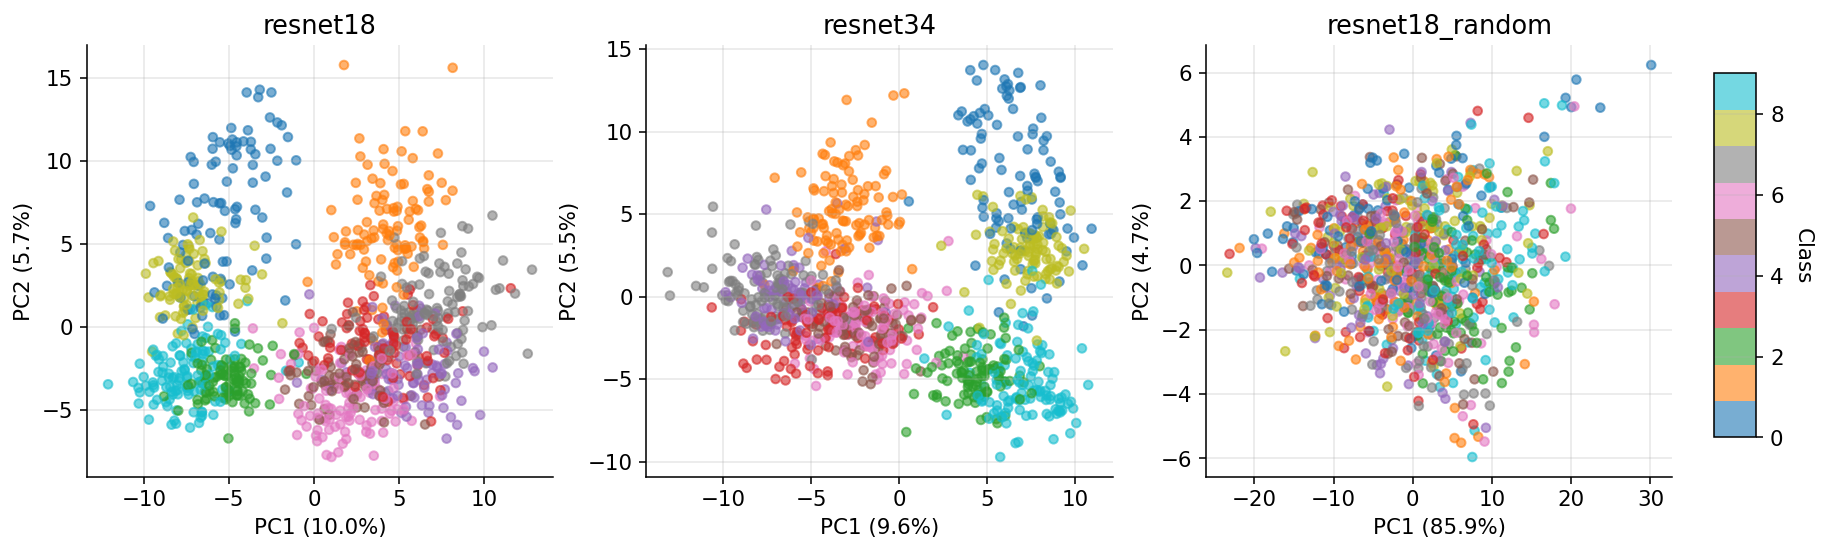

b5. 2D Visualization (PCA) complete.

All five organization analyses (b1-b5) have been completed!


In [19]:
# b5. Visualization — 2D PCA Projection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

last_scatter = None

for ax, model_name in zip(axes, cfg.model_names):
    Z_train = feature_store[model_name]["Z_train"]
    y_train = feature_store[model_name]["y_train"]
    
    # PCA to 2D
    pca_2d = PCA(n_components=2)
    Z_2d = pca_2d.fit_transform(Z_train)
    
    # Scatter plot colored by class
    last_scatter = ax.scatter(
        Z_2d[:, 0],
        Z_2d[:, 1],
        c=y_train,
        cmap="tab10",
        alpha=0.6,
        s=20
    )
    
    ax.set_title(f"{model_name}")
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.grid(alpha=0.3)

# Leave space on the right for the colorbar
fig.subplots_adjust(right=0.88)

# Add a colorbar axis manually on the right
cbar_ax = fig.add_axes([0.90, 0.18, 0.02, 0.65])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)

# Put tick labels and colorbar label on the right
cbar.ax.yaxis.set_ticks_position("right")
cbar.ax.yaxis.set_label_position("right")
cbar.set_label("Class", rotation=270, labelpad=15)

plt.show()

print("b5. 2D Visualization (PCA) complete.")
print(f"\nAll five organization analyses (b1-b5) have been completed!")